# Create Time Series of Temperature, Electricity Demand, and Wind and Solar Generation for a Given Event


In [1]:
# Start by importing the packages we need:
import os
import datetime

import pandas as pd
import matplotlib.pyplot as plt


## Set the Directory Structure

In [165]:
# Identify the data input and output directories:
hw_cs_data_dir =  '/Users/burl878/Documents/Code/code_repos/gdo_climate_toolsuite_visualizations/data/'
temp_data_dir =  '/Users/burl878/Documents/Code/code_repos/gdo_climate_toolsuite_visualizations/data/temperature_data/'
renew_data_dir =  '/Users/burl878/Documents/Code/code_repos/gdo_climate_toolsuite_visualizations/data/wind_solar_data/'
load_data_dir =  '/Users/burl878/Documents/Code/code_repos/gdo_climate_toolsuite_visualizations/data/load_data/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/gdo_climate_toolsuite_visualizations/plots/Event_Time_Series/'


## Write a Function to Process the Temperature Time Series Data


In [83]:
# Define a function to process the time series of temperature for a given NERC TPL-08 region:
def process_temperature_time_series(temp_data_dir: str, region: str):
    
    # Read in the raw time series data for all NERC regions:
    temp_df = pd.read_csv((temp_data_dir + 'NERC_Region_Daily_Temperature_1980_to_2024.csv'))
    
    # Subset to just the data for NERC region you want to use:
    subset_df = temp_df[(temp_df['Region'] == region)].copy()

    # Set 'Date' to a datetime variable:
    subset_df['Date'] = pd.to_datetime(subset_df['Date'])
    
    # Add the day of year to be used as an averaging parameter:
    subset_df['DoY'] = subset_df['Date'].dt.dayofyear

    # Calculate the mean T_Min and T_Max by day of year:
    subset_df['T_Min_Mean'] = subset_df.groupby('DoY')['T_Min'].transform('mean').round(2)
    subset_df['T_Max_Mean'] = subset_df.groupby('DoY')['T_Max'].transform('mean').round(2)

    # Calculate the temperature anomalies:
    subset_df['T_Min_Delta'] = subset_df['T_Min'] - subset_df['T_Min_Mean']
    subset_df['T_Max_Delta'] = subset_df['T_Max'] - subset_df['T_Max_Mean']
    
    # Only keep the columns we need:
    output_df = subset_df[['Date','T_Min','T_Min_Mean','T_Min_Delta','T_Max','T_Max_Mean','T_Max_Delta']].copy()
    
    return output_df


In [84]:
# Test the function:
temp_df = process_temperature_time_series(temp_data_dir = temp_data_dir, 
                                          region = 'PJM')

temp_df


,Date,T_Min,T_Min_Mean,T_Min_Delta,T_Max,T_Max_Mean,T_Max_Delta
147933,1980-01-01,27.01,25.97,1.04,41.06,40.95,0.11
147934,1980-01-02,25.18,25.09,0.09,37.69,39.69,-2.00
147935,1980-01-03,24.47,25.29,-0.82,37.14,39.34,-2.20
147936,1980-01-04,23.64,24.71,-1.07,33.08,39.79,-6.71
147937,1980-01-05,21.77,22.47,-0.70,31.76,38.03,-6.27
...,...,...,...,...,...,...,...
164365,2024-12-27,28.04,25.16,2.88,43.82,40.51,3.31
164366,2024-12-28,38.28,26.26,12.02,50.59,41.90,8.69
164367,2024-12-29,45.00,25.96,19.04,59.22,40.68,18.54
164368,2024-12-30,40.51,25.83,14.68,55.31,40.87,14.44


## Write a Function to Process the Load Time Series Data


In [150]:
def process_load_time_series(load_data_dir: str, region: str):

    # Read in the load data and subset to a given year:
    load_df = pd.read_csv((load_data_dir + 'NERC_Region_Hourly_Loads_1980_to_2024.csv'))
       
    # Only keep the columns we need:
    if region == 'CA' or region == 'PNW' or region == 'GB' or region == 'SW' or region == 'RM':
       subset_df = load_df[['Time_UTC', 'WECC', region]].copy()
       subset_df.rename(columns={'WECC': 'Interconnection_Load', region: 'Region_Load'}, inplace=True)
    if region == 'ERCOT':
       subset_df = load_df[['Time_UTC', 'ERCOT']].copy()
       subset_df['Region_Load'] = subset_df['ERCOT']
       subset_df.rename(columns={'ERCOT': 'Interconnection_Load'}, inplace=True)
    if region == 'SPP-N' or region == 'SPP-S' or region == 'MISO-N' or region == 'MISO-S' or region == 'SERC' or region == 'FL' or region == 'PJM' or region == 'NYISO' or region == 'ISONE':
       subset_df = load_df[['Time_UTC', 'EIC', region]].copy()
       subset_df.rename(columns={'EIC': 'Interconnection_Load', region: 'Region_Load'}, inplace=True)
    
    # Set 'Time_UTC' to a datetime variable:
    subset_df['Time_UTC'] = pd.to_datetime(subset_df['Time_UTC'])

    # Add the hour of year to be used as an averaging parameter:
    subset_df['HoY'] = (((subset_df['Time_UTC'].dt.dayofyear -1) * 24) + subset_df['Time_UTC'].dt.hour)
    
    # Calculate the mean load by hour of year:
    subset_df['Interconnection_Load_Mean'] = subset_df.groupby('HoY')['Interconnection_Load'].transform('mean').round(2)
    subset_df['Region_Load_Mean'] = subset_df.groupby('HoY')['Region_Load'].transform('mean').round(2)

    # Calculate the load anomalies:
    subset_df['Interconnection_Load_Delta'] = subset_df['Interconnection_Load'] - subset_df['Interconnection_Load_Mean']
    subset_df['Region_Load_Delta'] = subset_df['Region_Load'] - subset_df['Region_Load_Mean']

    # Only keep the columns we need:
    output_df = subset_df[['Time_UTC','Interconnection_Load','Interconnection_Load_Mean','Interconnection_Load_Delta','Region_Load','Region_Load_Mean','Region_Load_Delta']].copy()
    
    return output_df
    

In [152]:
# Test the function:
load_df = process_load_time_series(load_data_dir = load_data_dir, 
                                   region = 'PJM')

load_df


,Time_UTC,Interconnection_Load,Interconnection_Load_Mean,Interconnection_Load_Delta,Region_Load,Region_Load_Mean,Region_Load_Delta
0,1980-01-01 00:00:00,353874.11,370627.96,-16753.85,102809.05,109578.39,-6769.34
1,1980-01-01 01:00:00,351746.57,368357.46,-16610.89,101293.93,107958.26,-6664.33
2,1980-01-01 02:00:00,347782.68,364138.32,-16355.64,99459.65,106243.75,-6784.10
3,1980-01-01 03:00:00,338810.55,355509.85,-16699.30,97392.05,104394.59,-7002.54
4,1980-01-01 04:00:00,330037.08,346558.44,-16521.36,95599.34,102492.54,-6893.20
...,...,...,...,...,...,...,...
394481,2024-12-31 17:00:00,349837.01,367627.44,-17790.43,99916.80,106967.70,-7050.90
394482,2024-12-31 18:00:00,350277.97,366629.61,-16351.64,99620.06,106789.08,-7169.02
394483,2024-12-31 19:00:00,351628.91,365577.51,-13948.60,100244.41,106668.34,-6423.93
394484,2024-12-31 20:00:00,353273.58,365019.06,-11745.48,100944.22,106633.40,-5689.18


## Write a Function to Process the Wind and Solar Time Series Data


In [19]:
def process_renewables_time_series(renew_data_dir: str, renew_region: str):

    # Read in the load data and subset to a given year:
    renew_df = pd.read_csv((renew_data_dir + 'nerc_region_solar_wind_nolosses_historical_1980_2022.csv'))

    # Subset to just the region you want to plot:
    subset_renew_df = renew_df[renew_df['nerc_region'] == renew_region].copy()

    # Fix the time string to conform:
    subset_renew_df['datetime_utc'] = subset_renew_df['datetime_utc'].str.replace('T', ' ', regex=True).replace('Z', '', regex=True)
    
    # Set 'Time_UTC	' to a datetime variable add in the year:
    subset_renew_df['Time_UTC'] = pd.to_datetime(subset_renew_df['datetime_utc'])

    # Add the hour of year to be used as an averaging parameter:
    subset_renew_df['HoY'] = (((subset_renew_df['Time_UTC'].dt.dayofyear -1) * 24) + subset_renew_df['Time_UTC'].dt.hour)

    # Calculate the mean wind and solar by hour of year:
    subset_renew_df['Solar_Mean_MWh'] = subset_renew_df.groupby('HoY')['solar_gen_mwh'].transform('mean').round(2)
    subset_renew_df['Wind_Mean_MWh'] = subset_renew_df.groupby('HoY')['wind_gen_mwh'].transform('mean').round(2)
    
    # Only keep the columns we need:
    output_df = subset_renew_df[['Time_UTC', 'solar_gen_mwh', 'Solar_Mean_MWh', 'solar_cf', 'wind_gen_mwh', 'Wind_Mean_MWh', 'wind_cf']].copy()

    # Rename the columns because I'm OCD:
    output_df.rename(columns={'solar_gen_mwh': 'Solar_MWh', 'solar_cf': 'Solar_CF', 'wind_gen_mwh': 'Wind_MWh', 'wind_cf': 'Wind_CF'}, inplace=True)

    # Round the capacity factor values:
    output_df['Solar_CF'] = output_df['Solar_CF'].round(3)
    output_df['Wind_CF'] = output_df['Wind_CF'].round(3)
    
    return output_df
    

In [ ]:
# Test the function:
renew_df = process_renewables_time_series(renew_data_dir = renew_data_dir, 
                                          renew_region = 'NWPP')

renew_df


## Read in the Heat Wave or Cold Snap Library


In [10]:
# Extract the heat wave or cold snap library data for a given NERC region:
hw_cs_df = pd.read_csv((hw_cs_data_dir + 'hw_library_expanded.csv'))

hw_cs_df


,UID,NERC,Region,Start,End,Center,Center_DOY,T_Max_Min,Duration,Regions_Impacted
0,HW_NERC1_Event1,1,CA,1980-07-23,1980-08-02,1980-07-28,210,94.16,11,5.0
1,HW_NERC1_Event2,1,CA,1980-08-10,1980-08-11,1980-08-10,223,90.64,2,3.0
2,HW_NERC1_Event3,1,CA,1980-09-30,1980-10-03,1980-10-01,275,93.17,4,1.0
3,HW_NERC1_Event4,1,CA,1981-08-06,1981-08-09,1981-08-07,219,92.93,4,2.0
4,HW_NERC1_Event5,1,CA,1981-08-27,1981-08-28,1981-08-27,239,92.01,2,1.0
...,...,...,...,...,...,...,...,...,...,...
1723,HW_NERC16_Event96,16,SW,2024-06-06,2024-06-07,2024-06-06,158,99.58,2,2.0
1724,HW_NERC16_Event97,16,SW,2024-06-13,2024-06-13,2024-06-13,165,99.01,1,2.0
1725,HW_NERC16_Event98,16,SW,2024-07-03,2024-07-14,2024-07-08,190,101.40,12,8.0
1726,HW_NERC16_Event99,16,SW,2024-08-05,2024-08-05,2024-08-05,218,98.97,1,5.0


## Make the Plot


In [175]:
def plot_hw_event_time_series(event: str, window: int, hw_cs_data_dir: str, temp_data_dir: str, load_data_dir: str, renew_data_dir: str, 
                              image_output_dir: str, image_resolution: int, save_images=False):

    # Read in the heat wave event library:
    hw_cs_df = pd.read_csv((hw_cs_data_dir + 'hw_library_expanded.csv'))
    
    # Subset to just the event specified:
    hw_cs_df = hw_cs_df.loc[hw_cs_df['UID'] == event].copy()

    # Extract the event parameters used to query the functions defined above:
    region = hw_cs_df.loc[hw_cs_df['UID'] == event, 'Region'].item()
    start_date = pd.to_datetime(hw_cs_df.loc[hw_cs_df['UID'] == event, 'Start'].item())
    end_date = pd.to_datetime(hw_cs_df.loc[hw_cs_df['UID'] == event, 'End'].item())
    
    # Read in NERC region name file and extract the name:
    nerc = pd.read_csv((hw_cs_data_dir + 'nerc_tpl08_region_names.csv'))
    nerc_name = nerc.loc[nerc['short_name'] == region, 'long_name'].item()
        
    # Process the temperature time series and subset the data to just dates within the time window:
    temp_df = process_temperature_time_series(temp_data_dir = temp_data_dir, region = region)
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_subset_df = temp_df[(temp_df['Date'] >= pd.to_datetime((start_date - pd.Timedelta(days=window)))) & (temp_df['Date'] <= pd.to_datetime((end_date + pd.Timedelta(days=window))))].copy()

    # Process the load time series and subset the data to just dates within the time window:
    load_df = process_load_time_series(load_data_dir = load_data_dir, region = region)
    load_df['Time_UTC'] = pd.to_datetime(load_df['Time_UTC'])
    load_subset_df = load_df[(load_df['Time_UTC'] >= pd.to_datetime(start_date - pd.Timedelta(days=window))) & (load_df['Time_UTC'] <= pd.to_datetime(end_date + pd.Timedelta(days=window)))].copy()

    # Process the wind and solar time series and subset the data to just dates within the time window:
    #renew_df = process_renewables_time_series(renew_data_dir = renew_data_dir, 
     #                                         renew_region = renew_region)
    #renew_subset_df = renew_df[(renew_df['Time_UTC'] >= pd.to_datetime(start_day)) & (renew_df['Time_UTC'] <= pd.to_datetime(end_day))].copy()

    # Calculate the minimum and maximum values to be used in plotting:
    temp_min = min([temp_subset_df['T_Max'].min(),temp_subset_df['T_Max_Mean'].min()]) - 3
    temp_max = max([temp_subset_df['T_Max'].max(),temp_subset_df['T_Max_Mean'].max()]) + 3
    load_min = min([load_subset_df['Region_Load'].min(),load_subset_df['Region_Load_Mean'].min()]) * 0.9
    load_max = max([load_subset_df['Region_Load'].max(),load_subset_df['Region_Load_Mean'].max()]) * 1.1
    
    # Calculate the temperature and load anomalies:
    temp_peak = temp_subset_df['T_Max'].max().round(1)
    temp_anom = temp_subset_df.loc[temp_subset_df['T_Max'].idxmax(), ['T_Max_Delta']].item().round(1)
    load_peak = load_subset_df['Region_Load'].max().round(0)
    load_anom = load_subset_df.loc[load_subset_df['Region_Load'].idxmax(), ['Region_Load_Delta']].item().round(0)
        
    # Make the plot:
    plt.figure(figsize=(25,30))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True
    
    ax1 = plt.subplot(411)
    plt.plot(temp_subset_df['Date'], temp_subset_df['T_Max'], color='r', linestyle='-', linewidth=3)
    plt.plot(temp_subset_df['Date'], temp_subset_df['T_Max_Mean'], color='k', linestyle='--', linewidth=2)
    plt.fill_between([pd.to_datetime(start_date), pd.to_datetime(end_date)], temp_min, temp_max, color='r', alpha=0.15)
    plt.text(0.8, 0.925, ('Hottest Temperature = ' + str(temp_peak) + '$^\circ$F'), fontsize=21, horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)
    plt.text(0.8, 0.825, ('Temperature Anomaly = ' + str(temp_anom) + '$^\circ$F'), fontsize=21, horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)
    plt.xlim([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))])
    plt.ylim([temp_min, temp_max])
    plt.ylabel('Max Temp. [$^\circ$F]', fontsize=18)
    plt.title(('Daily Maximum Temperature in ' + nerc_name))

    ax2 = plt.subplot(412)
    plt.plot(load_subset_df['Time_UTC'], load_subset_df['Region_Load'], color='m', linestyle='-', linewidth=3)
    plt.plot(load_subset_df['Time_UTC'], load_subset_df['Region_Load_Mean'], color='k', linestyle='--', linewidth=2)
    plt.fill_between([pd.to_datetime(start_date), pd.to_datetime(end_date)], load_min, load_max, color='r', alpha=0.15)
    plt.text(0.8, 0.925, ('Peak Demand = ' + str(load_peak) + ' MWh'), fontsize=21, horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)
    plt.text(0.8, 0.825, ('Peak Demand Anomaly = ' + str(load_anom) + ' MWh'), fontsize=21, horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)
    plt.xlim([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))])
    plt.ylim([load_min, load_max])
    plt.ylabel('Demand [MWh]', fontsize=18)
    plt.title(('Hourly Electricity Demand'))

    #plt.subplot(413)
    #plt.plot(renew_subset_df['Time_UTC'], renew_subset_df['Solar_MWh'], color='b', linestyle='-', linewidth=3)
    #plt.plot(renew_subset_df['Time_UTC'], renew_subset_df['Solar_Mean_MWh'], color='k', linestyle='--', linewidth=2)
    #plt.xlim([pd.to_datetime(start_day), pd.to_datetime(end_day)])
    #plt.ylim([0, (renew_subset_df['Solar_MWh'].max() + 25)])
    #plt.ylabel('Solar Gen. [MWh]', fontsize=18)
    #plt.title(('Hourly Solar Generation'))

    #plt.subplot(414)
    #plt.plot(renew_subset_df['Time_UTC'], renew_subset_df['Wind_MWh'], color='g', linestyle='-', linewidth=3)
    #plt.plot(renew_subset_df['Time_UTC'], renew_subset_df['Wind_Mean_MWh'], color='k', linestyle='--', linewidth=2)
    #plt.xlim([pd.to_datetime(start_day), pd.to_datetime(end_day)])
    #plt.ylim([0, (renew_subset_df['Wind_MWh'].max() + 25)])
    #plt.ylabel('Wind Gen. [MWh]', fontsize=18)
    #plt.title(('Hourly Wind Generation'))

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig((image_output_dir + 'HW/' + event + '.png'), dpi=image_resolution, bbox_inches='tight')
       #plt.close()

    return load_subset_df


,Time_UTC,Interconnection_Load,Interconnection_Load_Mean,Interconnection_Load_Delta,Region_Load,Region_Load_Mean,Region_Load_Delta
363480,2021-06-19 00:00:00,134636.21,112476.72,22159.49,22641.54,21364.28,1277.26
363481,2021-06-19 01:00:00,137114.85,115238.87,21875.98,22771.65,21554.58,1217.07
363482,2021-06-19 02:00:00,135553.85,115512.14,20041.71,22556.29,21618.03,938.26
363483,2021-06-19 03:00:00,131427.99,113748.34,17679.65,22108.70,21592.13,516.57
363484,2021-06-19 04:00:00,124723.86,109878.53,14845.33,21374.29,21172.84,201.45
...,...,...,...,...,...,...,...
363932,2021-07-07 20:00:00,117695.94,110146.58,7549.36,22575.67,21672.31,903.36
363933,2021-07-07 21:00:00,122861.66,113635.33,9226.33,22903.51,21965.30,938.21
363934,2021-07-07 22:00:00,128109.32,117295.47,10813.85,23174.78,22168.08,1006.70
363935,2021-07-07 23:00:00,131137.49,120203.08,10934.41,23107.54,22122.68,984.86


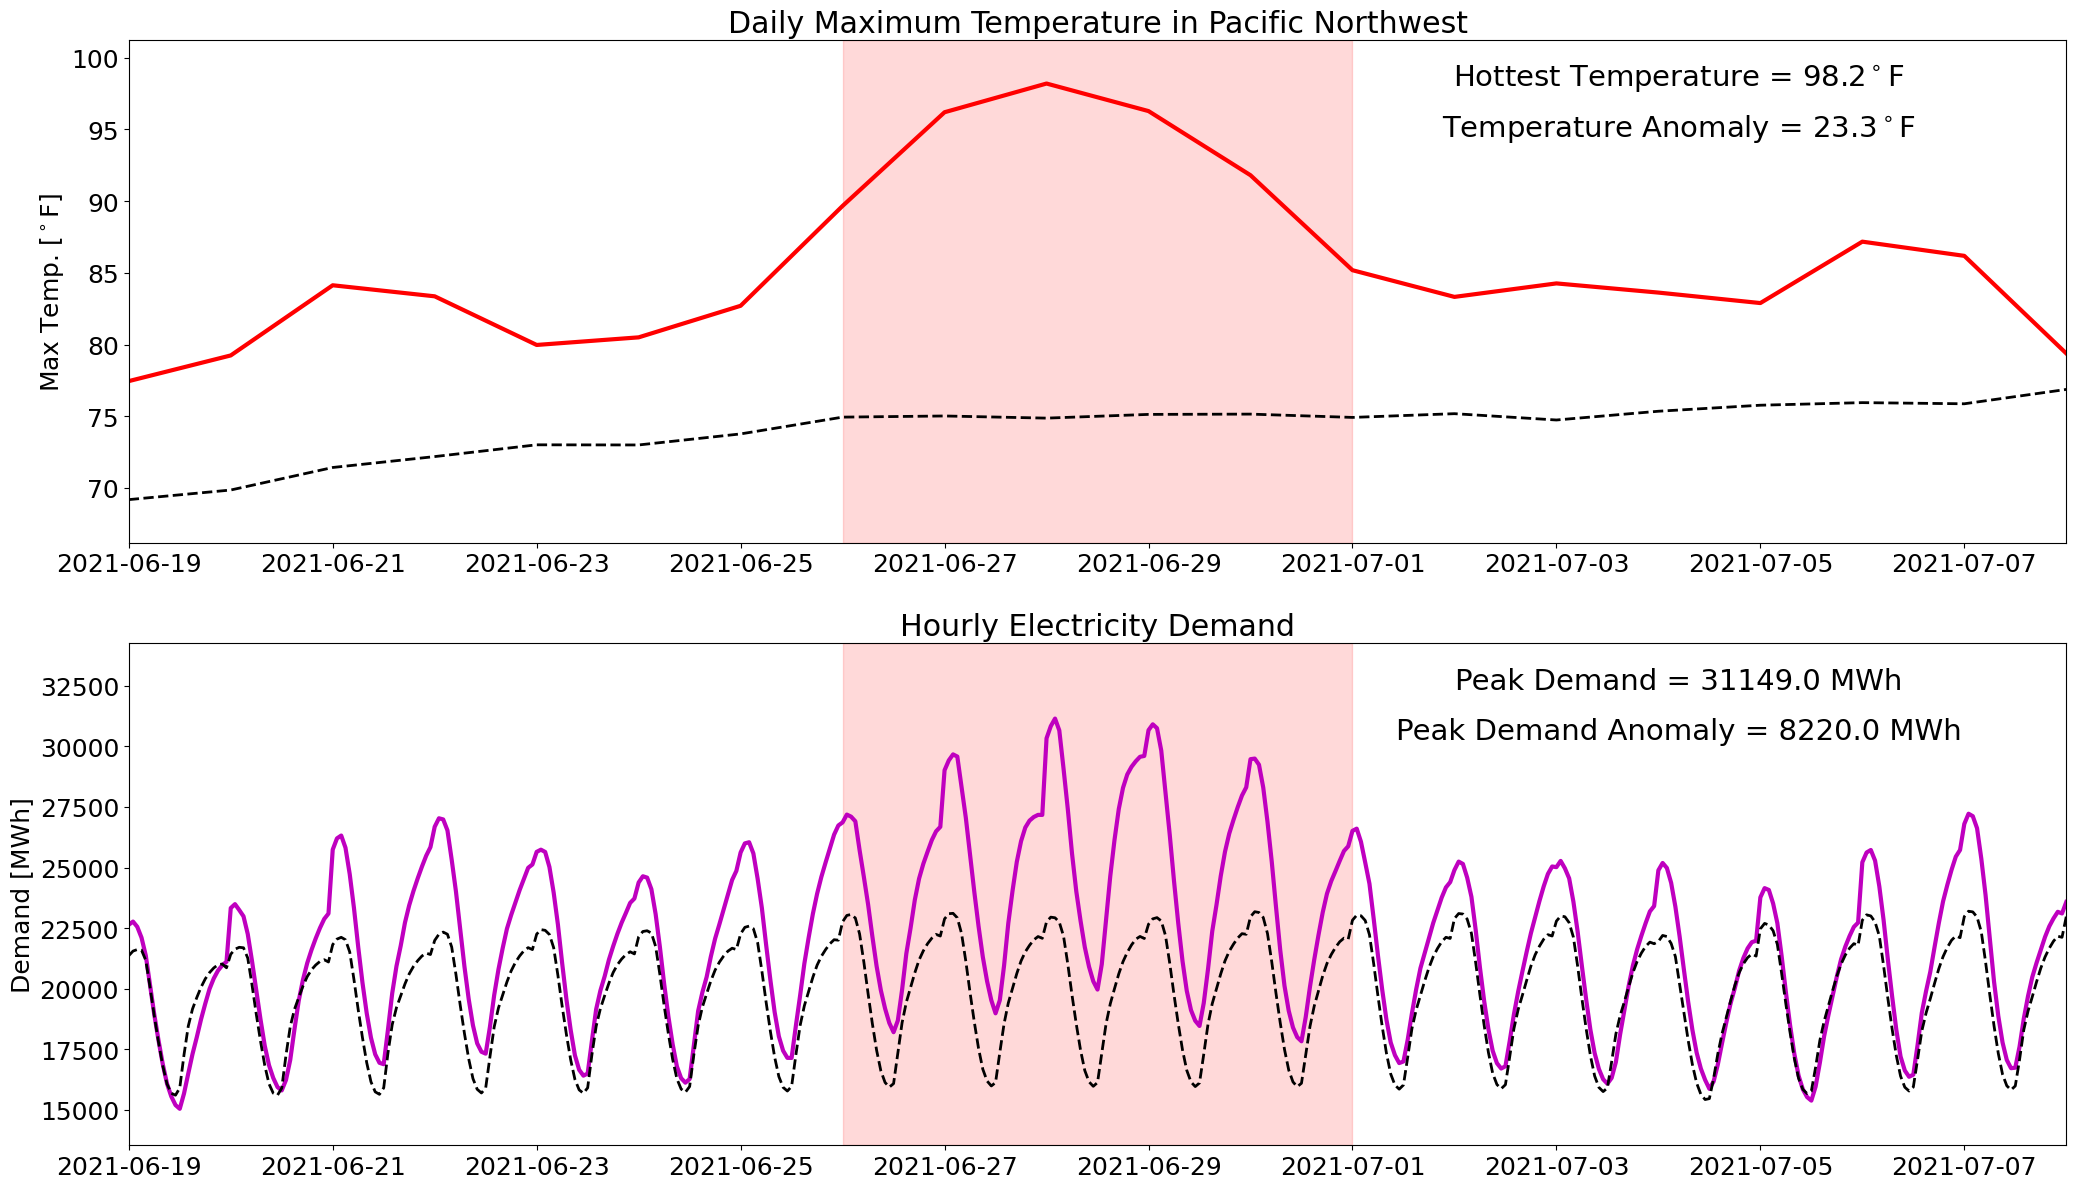

In [181]:
# Test the function:
output_df = plot_hw_event_time_series(event = 'HW_NERC11_Event105',
                                      window = 7, # Days before and after the start of the event to make the plot
                                      hw_cs_data_dir = hw_cs_data_dir,
                                      temp_data_dir = temp_data_dir, 
                                      load_data_dir = load_data_dir,
                                      renew_data_dir = renew_data_dir,
                                      image_output_dir = image_output_dir, 
                                      image_resolution = 150, 
                                      save_images = False)

output_df
